# Setup


In [ ]:
!pip install -q datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-c

In [ ]:
!pip install -U -q evaluate transformers datasets>=2.14.5 accelerate>=0.27 mlflow 2>/dev/null

In [ ]:
# Section: Import Libraries and Load Data

import os
import warnings
from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    f1_score
)
from pathlib import Path
from tqdm import tqdm
import gc
import numpy as np
import pandas as pd
from datasets import Dataset, Image, ClassLabel
from transformers import (
    TrainingArguments,
    Trainer,
    ViTImageProcessor,
    ViTForImageClassification,
    DefaultDataCollator
)
import torch
from torch.utils.data import DataLoader
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomRotation,
    RandomResizedCrop,
    RandomHorizontalFlip,
    RandomAdjustSharpness,
    Resize,
    ToTensor
)
from PIL import ImageFile


In [ ]:
# Configurations and Initializations
warnings.filterwarnings("ignore")  # Ignore warning messages
ImageFile.LOAD_TRUNCATED_IMAGES = True  # Allow loading truncated images

In [ ]:
%%writefile kaggle.json
{"username":"kusugurrala","key":"fb783590e80e21512b0ec159f232a00e"}

Writing kaggle.json


# Data loading and Preprocessing

In [ ]:
def download_kaggle_dataset(dataset_path):

    os.system('pip install -q kaggle')

    # Check for kaggle.json file
    if not os.path.isfile('kaggle.json'):
        print("kaggle.json file not found. Please upload it.")
        return

    # Set up Kaggle directory and permissions
    os.system('mkdir -p ~/.kaggle')
    os.system('cp kaggle.json ~/.kaggle/')
    os.system('chmod 600 ~/.kaggle/kaggle.json')

    # Download the dataset
    os.system(f'kaggle datasets download -d {dataset_path}')

    # Unzip the dataset
    zip_file = f'{dataset_path.split("/")[-1]}.zip'
    os.system(f'unzip -q {zip_file}')

download_kaggle_dataset('manjilkarki/deepfake-and-real-images')

In [ ]:
from pathlib import Path

def explore_dataset_structure(dataset_path):
    # exploring the contents of dataset
    root = Path(dataset_path)
    print(f"Contents of '{dataset_path}':")
    for split_folder in sorted(root.iterdir()):
        if split_folder.is_dir():
            class_folders = [f.name for f in split_folder.iterdir() if f.is_dir()]
            print(f"{split_folder.name} -> {class_folders}")
            print('-' * 50)

explore_dataset_structure("Dataset")


Contents of 'Dataset':
Test -> ['Fake', 'Real']
--------------------------------------------------
Train -> ['Fake', 'Real']
--------------------------------------------------
Validation -> ['Fake', 'Real']
--------------------------------------------------


In [ ]:
def load_dataset(dataset_path):
    #loading the dataset inta a dataframe
    data = {'image': [], 'label': [], 'split': []}
    for split in ['Train', 'Validation', 'Test']:
        for label in os.listdir(os.path.join(dataset_path, split)):
            label_path = os.path.join(dataset_path, split, label)
            for img_file in os.listdir(label_path):
                data['image'].append(os.path.join(label_path, img_file))
                data['label'].append(label)
                data['split'].append(split)
    return pd.DataFrame(data)

df = load_dataset("Dataset")

In [ ]:
# The count of images in each split
class_counts = df.groupby(['split', 'label']).size().reset_index(name='count')
print(class_counts)

        split label  count
0        Test  Fake   5492
1        Test  Real   5413
2       Train  Fake  70001
3       Train  Real  70001
4  Validation  Fake  19641
5  Validation  Real  19787


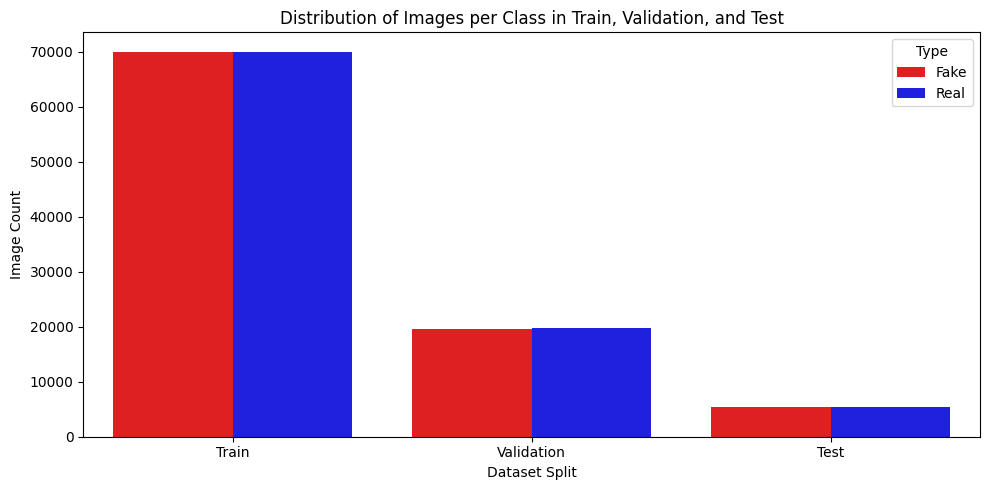

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Plotting the distribution of images in train, Validation and Test
image_counts = df.groupby(['split', 'label']).size().unstack(fill_value=0)
df_viz = pd.DataFrame(image_counts).reset_index().melt(
    id_vars="split", var_name="Type", value_name="Count"
)
df_viz.rename(columns={"split": "Dataset Split"}, inplace=True)
split_order = ["Train", "Validation", "Test"]
df_viz["Dataset Split"] = pd.Categorical(df_viz["Dataset Split"], categories=split_order, ordered=True)
df_viz = df_viz.sort_values("Dataset Split")
plt.figure(figsize=(10, 5))
sns.barplot(x="Dataset Split", y="Count", hue="Type", data=df_viz, palette=["red", "blue"])
plt.title("Distribution of Images per Class in Train, Validation, and Test")
plt.ylabel("Image Count")
plt.xlabel("Dataset Split")
plt.tight_layout()
plt.show()


In [ ]:
# The count of images in each class
class_totals = df['label'].value_counts().reset_index()
class_totals.columns = ['Class', 'Count']
print(class_totals)


  Class  Count
0  Real  95201
1  Fake  95134


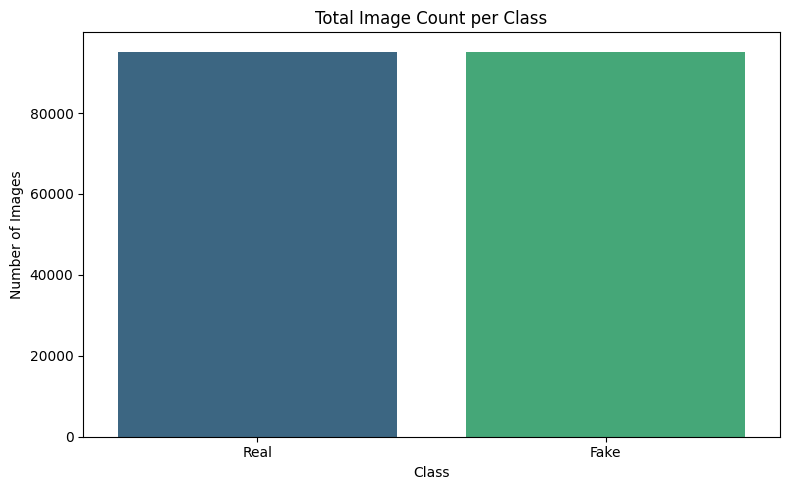

In [ ]:
#Plotting the distribution of classes
plt.figure(figsize=(8, 5))
sns.barplot(data=class_totals, x='Class', y='Count', palette="viridis")
plt.title("Total Image Count per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


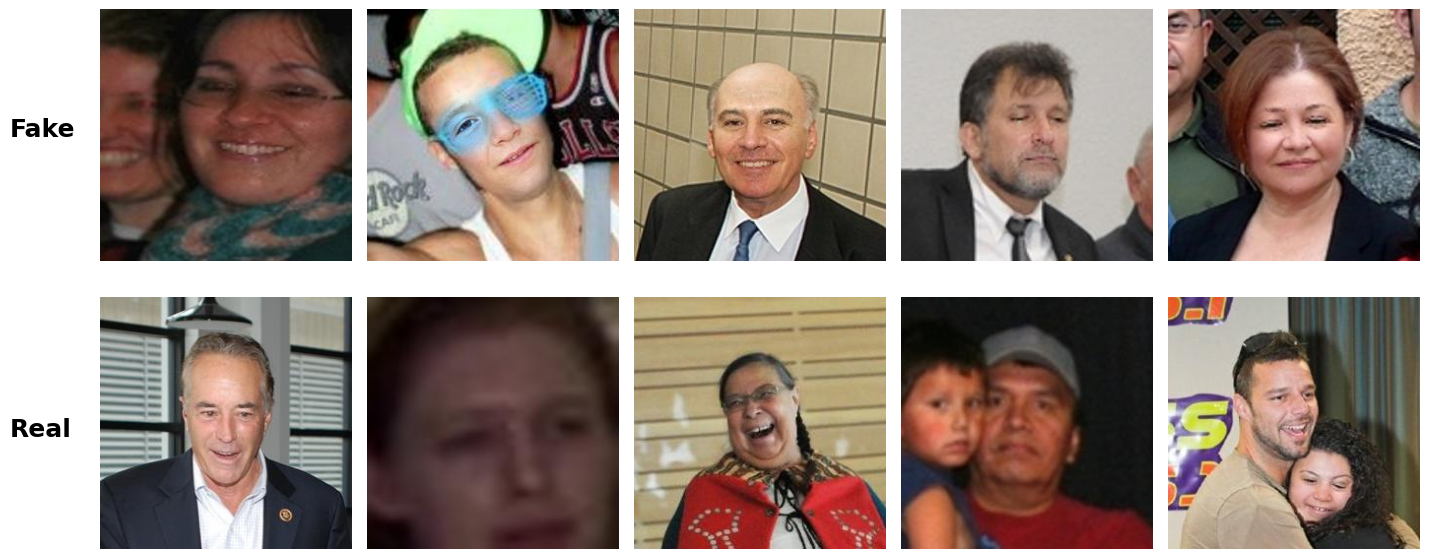

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def show_sample_images(df, split='Train', samples_per_class=5):
    #Shows the sample images
    classes = df[df['split'] == split]['label'].unique()
    num_classes = len(classes)
    fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(samples_per_class * 3, num_classes * 3))

    for i, label in enumerate(classes):
        sample_images = df[(df['split'] == split) & (df['label'] == label)].sample(samples_per_class)

        fig.text(0.05, 1 - (i + 0.5) / num_classes, label, fontsize=18, fontweight='bold', va='center')

        for j, img_path in enumerate(sample_images['image']):
            ax = axes[i][j] if num_classes > 1 else axes[j]
            img = Image.open(img_path)
            ax.imshow(img)
            ax.axis('off')

    plt.tight_layout(rect=[0.1, 0, 1, 1])
    plt.show()

show_sample_images(df, split='Train', samples_per_class=5)

In [ ]:
import os
import pandas as pd
from datasets import Dataset, ClassLabel, Features, Value, Image as HFImage
from torchvision.transforms import (
    Compose, Resize, RandomRotation, RandomAdjustSharpness, RandomHorizontalFlip,
    RandomResizedCrop, ColorJitter, ToTensor, Normalize
)
from transformers import ViTImageProcessor
from PIL import Image
import torch

# Prepare DataFrame
df_for_dataset = df[['image', 'label']].copy()

# Create Hugging Face Dataset
features = Features({
    'image': HFImage(),  # This will load the image from the path
    'label': Value('string')
})
dataset = Dataset.from_pandas(df_for_dataset, features=features)

# Label mapping
labels_list = sorted(df['label'].unique())  # e.g., ['Fake', 'Real']
ClassLabels = ClassLabel(num_classes=len(labels_list), names=labels_list)

def map_label2id(example):
    example['label'] = ClassLabels.str2int(example['label'])
    return example

dataset = dataset.map(map_label2id, batched=True)
dataset = dataset.cast_column('label', ClassLabels)

# Manual split using your existing 'split' column
train_data = dataset.select(df[df['split'] == 'Train'].index.tolist())
val_data   = dataset.select(df[df['split'] == 'Validation'].index.tolist())
test_data  = dataset.select(df[df['split'] == 'Test'].index.tolist())

# Prepare ViT processor
model_str = "dima806/deepfake_vs_real_image_detection"
processor = ViTImageProcessor.from_pretrained(model_str)
image_mean = processor.image_mean
image_std = processor.image_std
size = processor.size["height"]
print("ViT image size:", size)

# Define Deepfake-Aware Transformations
train_transforms = Compose([
    RandomResizedCrop(size, scale=(0.8, 1.0), ratio=(0.9, 1.1)),  # mild zoom/crop
    RandomHorizontalFlip(p=0.5),                                  # flip helps with pose variance
    RandomRotation(degrees=20),                                   # slight tilt
    ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),     # subtle lighting variation
    RandomAdjustSharpness(sharpness_factor=2),
    ToTensor(),
    Normalize(mean=image_mean, std=image_std)
])

val_transforms = Compose([
    Resize((size, size)),
    ToTensor(),
    Normalize(mean=image_mean, std=image_std)
])

# Apply transforms
def apply_transforms(examples, transforms):
    examples['pixel_values'] = [transforms(image.convert("RGB")) for image in examples['image']]
    return examples

train_data.set_transform(lambda examples: apply_transforms(examples, train_transforms))
val_data.set_transform(lambda examples: apply_transforms(examples, val_transforms))
test_data.set_transform(lambda examples: apply_transforms(examples, val_transforms))

# Output basic info
print("Train samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(test_data))
print("Label mapping:", ClassLabels.names)


Map:   0%|          | 0/190335 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/190335 [00:00<?, ? examples/s]

preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

ViT image size: 224
Train samples: 140002
Validation samples: 39428
Test samples: 10905
Label mapping: ['Fake', 'Real']


# Model Creation and Training

In [ ]:
def compute_metrics(eval_pred):
    predictions, label_ids = eval_pred
    predicted_labels = predictions.argmax(axis=1)
    acc_score = accuracy_score(label_ids, predicted_labels)
    f1 = f1_score(label_ids, predicted_labels, average='macro')
    roc_auc = roc_auc_score(label_ids, predictions[:, 1]) if len(set(label_ids)) == 2 else roc_auc_score(label_ids, predictions, multi_class="ovr")
    return {"accuracy": acc_score, "f1": f1, "roc_auc": roc_auc}
def predict_and_print_metrics(trainer, test_data):
    outputs = trainer.predict(test_data)
    print("Evaluation Metrics:", outputs.metrics)
    return outputs.label_ids, outputs.predictions.argmax(1)

# Load the ViT Model
model = ViTForImageClassification.from_pretrained(model_str, num_labels=len(ClassLabels.names))

# Set label mappings
id2label = {i: label for i, label in enumerate(ClassLabels.names)}
label2id = {label: i for i, label in enumerate(ClassLabels.names)}

model.config.id2label = id2label
model.config.label2id = label2id

print(f"✅ Trainable Parameters: {model.num_parameters(only_trainable=True) / 1e6:.2f} million")

# Device Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")
if device.type == "cuda":
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

✅ Trainable Parameters: 85.80 million
🚀 Using device: cuda
CUDA Device: Tesla T4


In [ ]:
output_dir = "deepfake_vs_real_image_detection"
training_args = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    learning_rate=5e-6,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.02,
    warmup_steps=50,
    remove_unused_columns=False,
    save_strategy='epoch',
    load_best_model_at_end=True,
    save_total_limit=1,
    report_to="none"
)

# DATA COLLATOR
def collate_fn(examples):
    pixel_values = torch.stack([example['pixel_values'] for example in examples])
    labels = torch.tensor([example['label'] for example in examples])
    return {'pixel_values': pixel_values, 'labels': labels}

# TRAINER
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

In [ ]:
print("📊 Evaluation before training:")
trainer.evaluate()

print("🚀 Training starts...")
trainer.train()

print("📈 Evaluation after training:")
evaluation_results = trainer.evaluate()
print("Evaluation Results:", evaluation_results)

# PREDICT ON TEST SET
prediction_results = trainer.predict(test_data)
print("Prediction Metrics:", prediction_results.metrics)

📊 Evaluation before training:


🚀 Training starts...


Epoch,Training Loss,Validation Loss,Model Preparation Time,Accuracy,F1,Roc Auc
1,0.044100,0.080480,0.004600,0.970224,0.970197,0.998425
2,0.034500,0.068592,0.004600,0.975322,0.975307,0.998622


📈 Evaluation after training:


Evaluation Results: {'eval_loss': 0.06859225034713745, 'eval_model_preparation_time': 0.0046, 'eval_accuracy': 0.9753221061174799, 'eval_f1': 0.9753067572737206, 'eval_roc_auc': 0.9986224787289454, 'eval_runtime': 511.1802, 'eval_samples_per_second': 77.131, 'eval_steps_per_second': 4.822, 'epoch': 2.0}
Prediction Metrics: {'test_loss': 0.09836862236261368, 'test_model_preparation_time': 0.0046, 'test_accuracy': 0.966895919303072, 'test_f1': 0.9668868974958285, 'test_roc_auc': 0.9954481260820536, 'test_runtime': 147.0706, 'test_samples_per_second': 74.148, 'test_steps_per_second': 4.637}


# Model evaluation and saving

In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, roc_auc_score
)
import shutil
import os
from transformers import pipeline


Evaluation Metrics: {'test_loss': 0.09836862236261368, 'test_model_preparation_time': 0.0046, 'test_accuracy': 0.966895919303072, 'test_f1': 0.9668868974958285, 'test_roc_auc': 0.9954481260820536, 'test_runtime': 142.9831, 'test_samples_per_second': 76.268, 'test_steps_per_second': 4.77}
Accuracy: 0.9669
F1 Score: 0.9669


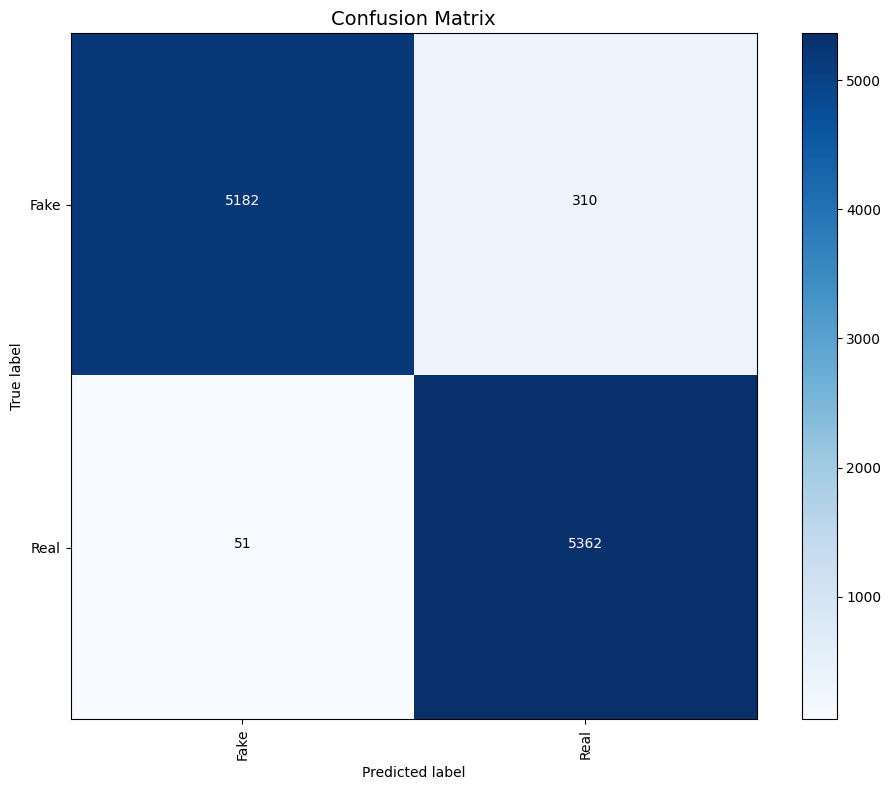


Classification report:

              precision    recall  f1-score   support

        Fake     0.9903    0.9436    0.9663      5492
        Real     0.9453    0.9906    0.9674      5413

    accuracy                         0.9669     10905
   macro avg     0.9678    0.9671    0.9669     10905
weighted avg     0.9680    0.9669    0.9669     10905



In [ ]:
def compute_metrics(eval_pred):
    predictions, label_ids = eval_pred
    predicted_labels = predictions.argmax(axis=1)
    acc_score = accuracy_score(label_ids, predicted_labels)
    f1 = f1_score(label_ids, predicted_labels, average='macro')
    roc_auc = roc_auc_score(label_ids, predictions[:, 1]) if len(set(label_ids)) == 2 else roc_auc_score(label_ids, predictions, multi_class="ovr")
    return {"accuracy": acc_score, "f1": f1, "roc_auc": roc_auc}
def predict_and_print_metrics(trainer, test_data):
    outputs = trainer.predict(test_data)
    print("Evaluation Metrics:", outputs.metrics)
    return outputs.label_ids, outputs.predictions.argmax(1)

# Confusion Matrix Plotting

def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues, figsize=(10, 8)):
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# Print Scores & Report

def calculate_and_print_scores(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")

def display_classification_report(y_true, y_pred, labels_list):
    print("\nClassification report:\n")
    print(classification_report(y_true, y_pred, target_names=labels_list, digits=4))

y_true, y_pred = predict_and_print_metrics(trainer, test_data)
calculate_and_print_scores(y_true, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, labels_list)

# Classification Report
display_classification_report(y_true, y_pred, labels_list)

Device set to use cuda:0


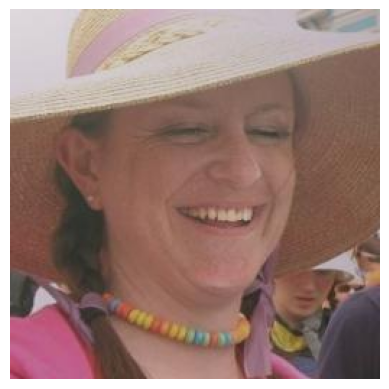

Prediction: [{'label': 'Fake', 'score': 0.9980693459510803}, {'label': 'Real', 'score': 0.001930698286741972}]
True Label: Fake


In [ ]:
def display_image_and_predict(pipe, test_data, index, id2label):
    image = test_data[index]["image"]
    plt.imshow(image)
    plt.axis('off')
    plt.show()
    prediction = pipe(image)
    print("Prediction:", prediction)
    print("True Label:", id2label[test_data[index]["label"]])

pipe = pipeline("image-classification", model=model, feature_extractor=processor)
display_image_and_predict(pipe, test_data, index=3, id2label=id2label)

In [ ]:
def save_and_zip_model(trainer, model_directory, zip_file_path):
    trainer.save_model(model_directory)
    if os.path.exists(model_directory):
        shutil.make_archive(base_name=zip_file_path.replace('.zip', ''), format='zip', root_dir=model_directory)
        print(f"Model zipped successfully at: {zip_file_path}")
    else:
        print(f"Directory not found: {model_directory}")

# Save and Zip Model
model_directory = "/content/deepfake_model"
zip_file_path = "/content/deepfake_model.zip"
save_and_zip_model(trainer, model_directory, zip_file_path)

# Download zipped model (if using Colab)
from google.colab import files
files.download(zip_file_path)

Model zipped successfully at: /content/deepfake_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>